Using device: cpu
Train size: 57, Val size: 10

Epoch 1/20


Training: 100%|██████████| 29/29 [08:50<00:00, 18.31s/it, loss=0]    


Train Loss: 0.6691 | Val Loss: 0.6236

Epoch 2/20


Training: 100%|██████████| 29/29 [09:12<00:00, 19.04s/it, loss=0.74] 


Train Loss: 0.4587 | Val Loss: 0.4360

Epoch 3/20


...

Train Loss: 0.4503 | Val Loss: 0.3500

Epoch 19/20


Training: 100%|██████████| 29/29 [09:06<00:00, 18.85s/it, loss=0.651]


Train Loss: 0.4463 | Val Loss: 0.3666

Epoch 20/20


Training: 100%|██████████| 29/29 [09:06<00:00, 18.84s/it, loss=0.391]


Train Loss: 0.5015 | Val Loss: 0.3437


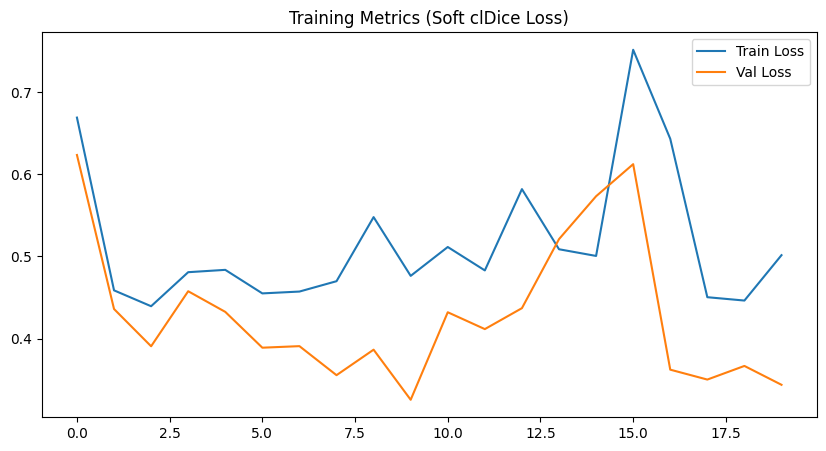

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import v2
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from cbDice.loss.skeletonize import Skeletonize
from cbDice.loss.soft_skeleton import SoftSkeletonize

# --- 1. LOSS FUNCTION INTEGRATION (SoftclDiceLoss) ---
# Ensure you have installed nnunetv2: pip install nnunetv2
# try:
#     from nnunetv2.training.loss.skeletonize import Skeletonize
#     from nnunetv2.training.loss.soft_skeleton import SoftSkeletonize
# except ImportError:
#     print("Error: nnunetv2 not installed. Please run: pip install nnunetv2")
#     # Placeholder to prevent crash if library is missing, but code won't run training
#     Skeletonize = None 
#     SoftSkeletonize = None

class SoftclDiceLoss(nn.Module):
    def __init__(self, iter_=10, smooth=1.):
        super(SoftclDiceLoss, self).__init__()
        self.smooth = smooth
        
        # Topology-preserving skeletonization
        self.t_skeletonize = Skeletonize(probabilistic=False, simple_point_detection='EulerCharacteristic')
        
        # Morphological skeletonization
        self.m_skeletonize = SoftSkeletonize(num_iter=iter_)

    def forward(self, y_pred, y_true, t_skeletonize_flag=False):
        """
        Args:
            y_pred (torch.Tensor): Model output logits with shape (b, c, x, y). 
            y_true (torch.Tensor): Ground truth masks with shape (b, 1, x, y).
        """
        # Separate foreground channel (assumes channel 1 is foreground)
        y_pred_fore = y_pred[:, 1:]
        
        # Handle cases with more than 2 channels if necessary
        if y_pred_fore.shape[1] > 1:
            y_pred_fore = torch.max(y_pred_fore, dim=1, keepdim=True)[0] 

        # Reconstruct binary logits: [Background, Foreground]
        y_pred_binary = torch.cat([y_pred[:, :1], y_pred_fore], dim=1)
        
        # Apply Softmax to get probabilities (Logits -> Probs)
        y_prob_binary = torch.softmax(y_pred_binary, 1)
        y_pred_prob = y_prob_binary[:, 1] # Select foreground probability

        with torch.no_grad():
            # Binarize ground truth and fix shape
            if len(y_true.shape) == 4:
                y_true = y_true.squeeze(1)
            y_true = torch.where(y_true > 0, 1, 0).float()
            
            # Binarize predictions for hard skeletonization
            y_pred_hard = (y_pred_prob > 0.5).float()
        
            if t_skeletonize_flag:
                skel_pred_hard = self.t_skeletonize(y_pred_hard.unsqueeze(1)).squeeze(1)
                skel_true = self.t_skeletonize(y_true.unsqueeze(1)).squeeze(1)
            else:
                skel_pred_hard = self.m_skeletonize(y_pred_hard.unsqueeze(1)).squeeze(1)
                skel_true = self.m_skeletonize(y_true.unsqueeze(1)).squeeze(1)

        # Soft Skeletonization on probabilities
        skel_pred_prob = skel_pred_hard * y_pred_prob

        # Calculation of T_prec and T_sens
        tprec = (torch.sum(torch.multiply(skel_pred_prob, y_true)) + self.smooth) / \
                (torch.sum(skel_pred_prob) + self.smooth)    
        tsens = (torch.sum(torch.multiply(skel_true, y_pred_prob)) + self.smooth) / \
                (torch.sum(skel_true) + self.smooth)
        
        # clDice Loss
        cl_dice_loss = 1 - (2.0 * (tprec * tsens) / (tprec + tsens))

        return cl_dice_loss

# --- 2. DATASET DEFINITION ---
class SimpleVeinDataset(Dataset):
    def __init__(self, csv_file, image_dir, mask_dir, augment):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augment = augment

        if self.augment:
            self.elastic_transform = v2.ElasticTransform(alpha=50.0, sigma=5.0)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get image ID
        image_id = self.data.iloc[idx]['ImageID']
        
        # Load image and mask
        img_path = os.path.join(self.image_dir, f"{image_id}.png")
        mask_path = os.path.join(self.mask_dir, f"{image_id}.jpg")
        
        # Open and convert to grayscale
        image = Image.open(img_path).convert('L')
        mask = Image.open(mask_path).convert('L')
        
        # Convert to tensor and normalize
        image = torch.from_numpy(np.array(image)).float() / 255.0
        mask = torch.from_numpy(np.array(mask)).float() / 255.0

        # Add channel dimension
        image = image.unsqueeze(0)
        mask = mask.unsqueeze(0)

        # Apply data augmentation if specified
        if self.augment:
            stacked = torch.cat([image, mask], dim=0)
            stacked = self.elastic_transform(stacked)
            image, mask = stacked[0:1], stacked[1:2]
        
        return image, mask

# --- 3. MODEL DEFINITION (U-NET) ---
# class UNet(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super(UNet, self).__init__()
        
#         def conv_block(in_feat, out_feat):
#             return nn.Sequential(
#                 nn.Conv2d(in_feat, out_feat, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(out_feat),
#                 nn.ReLU(inplace=True),
#                 nn.Conv2d(out_feat, out_feat, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(out_feat),
#                 nn.ReLU(inplace=True)
#             )
        
#         self.encoder1 = conv_block(in_channels, 64)
#         self.encoder2 = conv_block(64, 128)
#         self.encoder3 = conv_block(128, 256)
#         self.encoder4 = conv_block(256, 512)
        
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         self.bottleneck = conv_block(512, 1024)
        
#         self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
#         self.decoder4 = conv_block(1024, 512)
#         self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
#         self.decoder3 = conv_block(512, 256)
#         self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
#         self.decoder2 = conv_block(256, 128)
#         self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
#         self.decoder1 = conv_block(128, 64)
        
#         self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

#     def forward(self, x):
#         e1 = self.encoder1(x)
#         p1 = self.pool(e1)
        
#         e2 = self.encoder2(p1)
#         p2 = self.pool(e2)
        
#         e3 = self.encoder3(p2)
#         p3 = self.pool(e3)
        
#         e4 = self.encoder4(p3)
#         p4 = self.pool(e4)
        
#         b = self.bottleneck(p4)
        
#         d4 = self.upconv4(b)
#         # Handle shape mismatch for skip connections
#         if d4.shape != e4.shape:
#             d4 = F.resize(d4, size=e4.shape[2:])
#         d4 = torch.cat((e4, d4), dim=1)
#         d4 = self.decoder4(d4)
        
#         d3 = self.upconv3(d4)
#         if d3.shape != e3.shape:
#             d3 = F.resize(d3, size=e3.shape[2:])
#         d3 = torch.cat((e3, d3), dim=1)
#         d3 = self.decoder3(d3)
        
#         d2 = self.upconv2(d3)
#         if d2.shape != e2.shape:
#             d2 = F.resize(d2, size=e2.shape[2:])
#         d2 = torch.cat((e2, d2), dim=1)
#         d2 = self.decoder2(d2)
        
#         d1 = self.upconv1(d2)
#         if d1.shape != e1.shape:
#             d1 = F.resize(d1, size=e1.shape[2:])
#         d1 = torch.cat((e1, d1), dim=1)
#         d1 = self.decoder1(d1)
        
#         # RETURN RAW LOGITS (Important for SoftclDiceLoss)
#         return self.final_conv(d1)

# --- MODEL DEFINITION (Updated for SoftclDiceLoss) ---
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()
        def conv_block(in_feat, out_feat):
            return nn.Sequential(
                nn.Conv2d(in_feat, out_feat, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_feat),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_feat, out_feat, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_feat),
                nn.ReLU(inplace=True)
            )
        self.encoder1 = conv_block(in_channels, 64)
        self.encoder2 = conv_block(64, 128)
        self.encoder3 = conv_block(128, 256)
        self.encoder4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = conv_block(512, 1024)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = conv_block(128, 64)
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
 
    def forward(self, x):
        e1 = self.encoder1(x)
        p1 = self.pool(e1)
        e2 = self.encoder2(p1)
        p2 = self.pool(e2)
        e3 = self.encoder3(p2)
        p3 = self.pool(e3)
        e4 = self.encoder4(p3)
        p4 = self.pool(e4)
        b = self.bottleneck(p4)
        d4 = self.upconv4(b)
        if d4.shape != e4.shape: d4 = F.resize(d4, size=e4.shape[2:])
        d4 = torch.cat((e4, d4), dim=1)
        d4 = self.decoder4(d4)
        d3 = self.upconv3(d4)
        if d3.shape != e3.shape: d3 = F.resize(d3, size=e3.shape[2:])
        d3 = torch.cat((e3, d3), dim=1)
        d3 = self.decoder3(d3)
        d2 = self.upconv2(d3)
        if d2.shape != e2.shape: d2 = F.resize(d2, size=e2.shape[2:])
        d2 = torch.cat((e2, d2), dim=1)
        d2 = self.decoder2(d2)
        d1 = self.upconv1(d2)
        if d1.shape != e1.shape: d1 = F.resize(d1, size=e1.shape[2:])
        d1 = torch.cat((e1, d1), dim=1)
        d1 = self.decoder1(d1)
        # RETURNS RAW LOGITS (2 Channels)
        return self.final_conv(d1)

# --- 4. SETUP AND TRAINING ---

def main():
    # CONFIGURATION
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    BATCH_SIZE = 2  # Adjust based on your VRAM
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-4
    
    # PATHS (Update these to your local paths)
    CSV_FILE = '../Dataset Simplified/dataset.csv'
    IMAGE_DIR = '../Dataset Simplified/Images'
    MASK_DIR = '../Dataset Simplified/Masks'
    
    print(f"Using device: {DEVICE}")

    # DATA LOADING (Simplified Split Logic)
    try:
        df = pd.read_csv(CSV_FILE)
        
        # Split by BatID to avoid leakage
        unique_bats = df['BatID'].unique()
        train_bats, temp_bats = train_test_split(unique_bats, test_size=0.3, random_state=42)
        val_bats, test_bats = train_test_split(temp_bats, test_size=0.5, random_state=42)
        
        train_idx = df[df['BatID'].isin(train_bats)].index
        val_idx = df[df['BatID'].isin(val_bats)].index
        
        full_dataset = SimpleVeinDataset(CSV_FILE, IMAGE_DIR, MASK_DIR, augment=False)
        train_dataset = Subset(full_dataset, train_idx) # Add augmentation wrapper here if needed
        val_dataset = Subset(full_dataset, val_idx)
        
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        
        print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
        
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Ensure paths are correct and dataset exists.")
        return

    # INITIALIZE MODEL
    # out_channels=2 is REQUIRED for SoftclDiceLoss (Background, Foreground)
    model = UNet(in_channels=1, out_channels=2).to(DEVICE)
    
    # INITIALIZE OPTIMIZER
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # INITIALIZE NEW LOSS
    criterion = SoftclDiceLoss(iter_=10, smooth=1e-5).to(DEVICE)

    # TRAINING LOOP
    train_losses = []
    val_losses = []
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        progress_bar = tqdm(train_loader, desc="Training")
        
        for images, masks in progress_bar:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            
            # Forward
            outputs = model(images) # Outputs are raw logits [B, 2, H, W]
            
            # Loss
            loss = criterion(outputs, masks)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
            
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        # VALIDATION
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)
                
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_running_loss += loss.item()
                
        epoch_val_loss = val_running_loss / len(val_loader)
        val_losses.append(epoch_val_loss)
        
        print(f"Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        
        # SAVE MODEL (Optional)
        # if (epoch + 1) % 5 == 0:
        #     torch.save(model.state_dict(), f'unet_cldice_epoch_{epoch+1}.pth')

    # PLOT RESULTS
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Training Metrics (Soft clDice Loss)')
    plt.legend()
    plt.show()

    # --- TESTING LOOP ---
def test_model(model, test_loader, device):
    model.eval()
    # Initialize metric trackers
    metrics = {
        'dice': [], 'iou': [], 'precision': [], 'recall': [], 'accuracy': []
    }
    print("Starting Testing...")
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Testing"):
            images = images.to(device)
            masks = masks.to(device)
            # 1. Forward Pass (Returns Logits: [B, 2, H, W])
            logits = model(images)
            # 2. Convert to Probabilities (Softmax across channels)
            probs = torch.softmax(logits, dim=1)
            # 3. Select Foreground Channel (Index 1) & Binarize
            # probs[:, 1, :, :] gives the probability map for the vein
            preds = (probs[:, 1, :, :] > 0.5).float()
            # Ensure masks are binary (0 or 1)
            masks = (masks > 0.5).float()
            # Remove channel dim from masks if needed to match preds [B, H, W]
            if masks.shape[1] == 1:
                masks = masks.squeeze(1)
            # --- Calculate Metrics (Per Batch) ---
            # Smoothing to avoid division by zero
            smooth = 1e-6
            # Flatten tensors
            preds_flat = preds.view(-1)
            masks_flat = masks.view(-1)
            # Intersection & Union
            intersection = (preds_flat * masks_flat).sum()
            union = preds_flat.sum() + masks_flat.sum()
            # Dice
            dice = (2. * intersection + smooth) / (union + smooth)
            # IoU
            iou = (intersection + smooth) / (union - intersection + smooth)
            # Precision
            precision = (intersection + smooth) / (preds_flat.sum() + smooth)
            # Recall (Sensitivity)
            recall = (intersection + smooth) / (masks_flat.sum() + smooth)
            # Accuracy
            accuracy = (preds_flat == masks_flat).float().mean()
            # Store metrics
            metrics['dice'].append(dice.item())
            metrics['iou'].append(iou.item())
            metrics['precision'].append(precision.item())
            metrics['recall'].append(recall.item())
            metrics['accuracy'].append(accuracy.item())
 
    # Calculate averages
    avg_metrics = {k: np.mean(v) for k, v in metrics.items()}
    print("\nTest Results:")
    print(f"Dice Score: {avg_metrics['dice']:.4f}")
    print(f"IoU Score:  {avg_metrics['iou']:.4f}")
    print(f"Precision:  {avg_metrics['precision']:.4f}")
    print(f"Recall:     {avg_metrics['recall']:.4f}")
    print(f"Accuracy:   {avg_metrics['accuracy']:.4f}")
    return avg_metrics
 
# Run the test
# IMPORTANT: Ensure out_channels=2 when initializing
model = UNet(in_channels=1, out_channels=2).to(device)
 
# Load your weights (ensure the path is correct)
# model.load_state_dict(torch.load('unet_cldice_epoch_20.pth'))
 
test_metrics = test_model(model, test_loader, device)

def visualize_prediction(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        # Add batch dimension if missing
        if len(image_tensor.shape) == 3:
            image_tensor = image_tensor.unsqueeze(0)
        logits = model(image_tensor.to(device))
        # --- NEW LOGIC ---
        probs = torch.softmax(logits, dim=1)
        pred_mask = probs[0, 1, :, :].cpu().numpy() # Get foreground channel
        # -----------------
        return pred_mask

if __name__ == "__main__":
    main()
